# 03_05 Clipping Data to Bounds

## 1. Introduction
This notebook performs spatial clipping of the Canadian Digital Elevation Model (CDEM) using the previously defined Waterloo Region boundary.

In the previous notebook, both datasets were:
- analyzed for compatibility
- reprojected into a common coordinate system
- verified to overlap spatially

This ensures that clipping can now be performed safely without coordinate mismatch or spatial misalignment.

The goal of this step is to extract only the portion of the elevation model that falls within the Waterloo Region boundary, producing a clean terrain dataset for downstream hydrological analysis.

## 2. Imports

Import core geospatial and visualization libraries used in this notebook:

In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

import numpy as np
import matplotlib.pyplot as plt

## 3. Load Required Data

In [2]:
# -------------------------
# File paths
# -------------------------
dem_path = "../../data/Elevation/CDEM/DEM.tif"
boundary_path = "../../data/Boundaries/boundary_projected.geojson"

# -------------------------
# Load boundary
# -------------------------
boundary_proj = gpd.read_file(boundary_path)

# -------------------------
# Load DEM metadata ONLY (lightweight open)
# -------------------------
with rasterio.open(dem_path) as src:
    dem_meta = src.meta.copy()
    dem_crs = src.crs
    dem_bounds = src.bounds

print("DEM CRS:", dem_crs)
print("Boundary CRS:", boundary_proj.crs)

DEM CRS: EPSG:4617
Boundary CRS: EPSG:4617


## 4. Clip DEM to Boundary

Note that we use rasterio to open the dem_path and didn't load the data in the load data section because rasterio.mask.mask() requires a dataset object, not an array, so there was no benefit to loading it and storing it as an array only to reopen it later.

In [3]:
with rasterio.open(dem_path) as src:

    clipped_dem, transform = mask(
        src,
        boundary_proj.geometry,
        crop=True
    )

## 5. Convert to Working Array and Clean NoData Values

Once we load the data and clip it, we want to store the data in a working array in local memory so that we can operate on it without having to reload the data eahc time we need it. Also we have to clean the NoData Values.

Raster datasets often contain placeholder values that represent missing or invalid data (commonly called "NoData" values).

These values are not part of the real elevation surface and must be converted to `NaN` (Not a Number) so that:
- they are ignored in calculations
- they do not distort visualizations
- statistical operations (min, max, mean) remain accurate

This step ensures the clipped elevation surface reflects only valid terrain data.
    

In [4]:
elevation = clipped_dem[0]
nodata = dem_meta["nodata"]

elevation = np.where(
    elevation == nodata,
    np.nan,
    elevation
)

## 6. Visualize Clipped Terrain

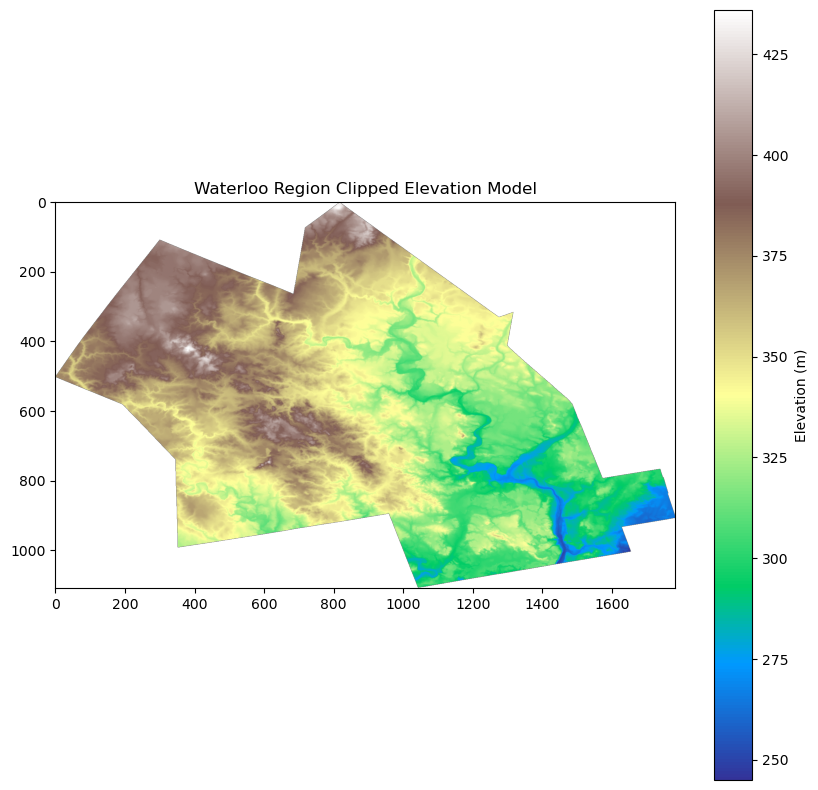

In [5]:
plt.figure(figsize=(10,10))

img = plt.imshow(
    elevation,
    cmap="terrain"
)

plt.colorbar(img, label="Elevation (m)")
plt.title("Waterloo Region Clipped Elevation Model")
plt.axis("on")

plt.show()

## 7. Optional: Save Clipped DEM as Output Raster

Here we have the option to save the clipped data so we do not need to repeat this step later. In some cases if you are doing environmental analysis you may not want to clip the data to the regional bounds. For example if you want to see how envrionmental conditions affect the area, then you may want to include some buffer space around the region so that you get a good sense of the boundary conditions and how areas outside the boundary influence events inside the boundary. 

In [6]:
profile = dem_meta.copy()

profile.update(
    height=elevation.shape[0],
    width=elevation.shape[1],
    transform=transform
)

with rasterio.open(
    "../../data/clipped_dem.tif",
    "w",
    **profile
) as dst:
    dst.write(clipped_dem)